# 03 — DEM Feature Extraction

Derive topographic statistics per grid cell from the clipped DEM.

Features computed pixel-by-pixel then aggregated to cell level via zonal statistics:

| Feature | Description |
|---|---|
| `elev_mean/min/max` | Elevation (m) |
| `elev_dev_mean` | Deviation from mean elevation (local position) |
| `total_relief` | elev_max − elev_min (vertical relief within cell) |
| `slope_mean/max` | Slope (degrees) |
| `aspect_mean_sin/cos` | Aspect encoded as sin/cos to handle 0/360 wrap |
| `curve_mean` | Total curvature |
| `pro_curve_mean` | Profile curvature (flow concentration) |
| `plan_curve_mean` | Plan curvature (convergence/divergence) |
| `slope_x / slope_y` | Slope gradient projected onto N-S and E-W axes |
| `dist_coast_m` | Distance from each cell centroid to the coastline (m) |

Output: `../data/plot_elev_features.pkl`

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

UTM_CRS  = 'EPSG:32604'
DEM_PATH = '../data/DEM/kona_DEM_utm.tif'

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# Load grid
grid = pd.read_pickle('../data/polygons/kona_grid.pkl').to_crs(UTM_CRS)
print(f'Grid cells: {len(grid)}')

# Load DEM in UTM
with rasterio.open(DEM_PATH) as src:
    dem       = src.read(1).astype('float64')
    transform = src.transform
    nodata    = src.nodata
    xres      = transform.a   # pixel width  (m)
    yres      = transform.e   # pixel height (m, negative)

dem = np.where(dem == nodata, np.nan, dem)
print(f'DEM shape: {dem.shape},  elev range: {np.nanmin(dem):.0f}–{np.nanmax(dem):.0f} m')

Grid cells: 10211
DEM shape: (7849, 6066),  elev range: -1–1297 m


In [3]:
# ── Compute pixel-level topographic derivatives ─────────────────────────────
dy, dx = np.gradient(dem, abs(yres), abs(xres))

# Second derivatives for curvature
dxx, dxy = np.gradient(dx, abs(yres), abs(xres))
dyx, dyy = np.gradient(dy, abs(yres), abs(xres))

# Total curvature (Laplacian)
curvature   = dxx + dyy

# Profile curvature (in direction of steepest descent)
profile_curv = (
    (dxx * dx**2 + 2 * dxy * dx * dy + dyy * dy**2)
    / ((dx**2 + dy**2) * (1 + dx**2 + dy**2)**1.5 + 1e-9)
)

# Plan curvature (contour curvature)
plan_curv = (
    (dxx * dy**2 - 2 * dxy * dx * dy + dyy * dx**2)
    / ((dx**2 + dy**2) * (1 + dx**2 + dy**2)**0.5 + 1e-9)
)

# Slope (degrees)
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# Aspect (degrees, 0 = North)
aspect_deg = (np.degrees(np.arctan2(-dx, dy)) + 360) % 360

# Elevation deviation from scene mean
elev_dev = dem - np.nanmean(dem)

print('Derivatives computed.')

/home/simonhans/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in remainder


Derivatives computed.


In [4]:
# ── Zonal statistics per grid cell ──────────────────────────────────────────
def zs(array, label):
    """Run zonal_stats for a raster array; return list of dicts."""
    return zonal_stats(grid, array, affine=transform, nodata=np.nan,
                       stats=['mean', 'min', 'max'])

print('Running zonal statistics (may take a moment)...')
slope_stats   = zs(slope_deg,    'slope')
aspect_stats  = zs(aspect_deg,   'aspect')
elev_stats    = zs(dem,          'elev')
dev_stats     = zs(elev_dev,     'elev_dev')
curv_stats    = zs(curvature,    'curv')
pro_curv_stats = zs(profile_curv,'pro_curv')
plan_curv_stats = zs(plan_curv,  'plan_curv')
print('Done.')

Running zonal statistics (may take a moment)...
Done.


In [5]:
# ── Assemble per-cell feature DataFrame ─────────────────────────────────────
def s(stats, key): return [d[key] for d in stats]

df = pd.DataFrame({
    'plot_id': grid['plot_id'].values,
    'label':   grid['label'].values,

    'slope_mean':  s(slope_stats, 'mean'),
    'slope_max':   s(slope_stats, 'max'),

    'aspect_mean': s(aspect_stats, 'mean'),

    'elev_min':    s(elev_stats,  'min'),
    'elev_max':    s(elev_stats,  'max'),
    'elev_mean':   s(elev_stats,  'mean'),

    'elev_dev_mean': s(dev_stats, 'mean'),

    'curve_mean':     s(curv_stats,      'mean'),
    'pro_curve_mean': s(pro_curv_stats,  'mean'),
    'plan_curve_mean':s(plan_curv_stats, 'mean'),
})

# Derived relief
df['total_relief']     = df['elev_max']  - df['elev_min']
df['total_relief_log'] = np.log1p(df['total_relief'])
df['local_relief']     = df['elev_mean'] - df['elev_min']

# Aspect → sin/cos encoding (handles 0/360 wrap) for ML features
df['aspect_sin'] = np.sin(np.radians(df['aspect_mean']))
df['aspect_cos'] = np.cos(np.radians(df['aspect_mean']))
# Keep aspect_mean in degrees for interpretability / plotting

# Slope gradient components (slope projected onto N/E axes)
df['slope_rad']  = np.radians(df['slope_mean'])
df['slope_grad'] = np.tan(df['slope_rad'])
df['slope_x']    = df['slope_grad'] * df['aspect_cos']
df['slope_y']    = df['slope_grad'] * df['aspect_sin']
df = df.drop(columns=['slope_mean', 'slope_rad', 'slope_grad'])

df.head(3)

,plot_id,label,slope_max,aspect_mean,elev_min,elev_max,elev_mean,elev_dev_mean,curve_mean,pro_curve_mean,plan_curve_mean,total_relief,total_relief_log,local_relief,aspect_sin,aspect_cos,slope_x,slope_y
0,0,0,4.100017,249.643587,200.159912,205.109070,203.062178,-286.802064,-0.000024,-0.000147,0.000123,4.949158,1.783250,2.902266,-0.937547,-0.347859,-0.011413,-0.030761
1,1,0,6.252050,185.952586,202.718872,205.513992,203.876214,-285.988027,-0.000047,-0.000121,0.000073,2.795120,1.333716,1.157342,-0.103705,-0.994608,-0.031552,-0.003290
2,2,0,7.421051,146.896151,200.159073,205.495987,202.880724,-286.983518,0.000384,0.000141,0.000243,5.336914,1.846392,2.721651,0.546158,-0.837682,-0.035150,0.022917


In [6]:
# ── Distance to coast ────────────────────────────────────────────────────────
# Approximate coastline as the bounding box seaward edge.
# For precision, load a NOAA/OSM coastline shapefile and use nearest-neighbor.
# Here we use a simple proxy: distance from cell centroid to the western coast
# at fixed longitude -156.20 (approximate shoreline).

centroids = grid.geometry.centroid
# Project centroid lon to distance from coast (rough — replace with real coastline)
centroids_ll = centroids.to_crs('EPSG:4326')
COAST_LON = -156.20  # approximate westernmost edge of study region
# 1° longitude ≈ 102 km at 19-20°N Hawaii
DEG_TO_M = 102_000
df['dist_coast_m'] = (centroids_ll.x - COAST_LON).abs() * DEG_TO_M

# Better approach (uncomment when coastline shapefile is available):
# from shapely.ops import nearest_points
# coast = gpd.read_file('path/to/coastline.shp').to_crs(UTM_CRS)
# coast_geom = coast.unary_union
# df['dist_coast_m'] = [
#     cent.distance(nearest_points(cent, coast_geom)[1])
#     for cent in centroids
# ]

print('dist_coast_m range:', df['dist_coast_m'].min(), '–', df['dist_coast_m'].max())

dist_coast_m range: 19933.07981391689 – 77685.50694028221


In [7]:
# ── Attach geometry and save ─────────────────────────────────────────────────
gdf_features = gpd.GeoDataFrame(
    df.merge(grid[['plot_id', 'geometry']], on='plot_id'),
    geometry='geometry', crs=UTM_CRS
).to_crs('EPSG:4326')

gdf_features.to_pickle('../data/plot_elev_features.pkl')
print('Saved ../data/plot_elev_features.pkl')
print(gdf_features.drop(columns='geometry').describe().round(2))

Saved ../data/plot_elev_features.pkl
        plot_id     label  slope_max  aspect_mean  elev_min  elev_max  \
count  10211.00  10211.00   10179.00     10179.00  10182.00  10182.00   
mean    5105.00      0.05      19.63       221.01    470.61    509.66   
std     2947.81      0.21       8.52        59.03    270.60    274.01   
min        0.00      0.00       0.00         0.00     -0.53     -0.36   
25%     2552.50      0.00      14.85       174.25    250.28    287.15   
50%     5105.00      0.00      18.68       247.00    465.43    506.65   
75%     7657.50      0.00      22.79       262.24    676.08    719.11   
max    10210.00      1.00      76.50       306.31   1284.34   1296.63   

       elev_mean  elev_dev_mean  curve_mean  pro_curve_mean  plan_curve_mean  \
count   10182.00       10182.00    10179.00        10177.00          10177.0   
mean      490.07           0.21        0.00           -0.00              0.0   
std       272.34         272.34        0.00            0.00      

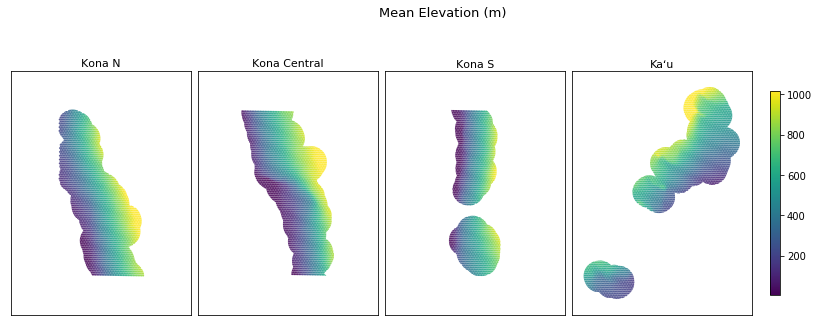

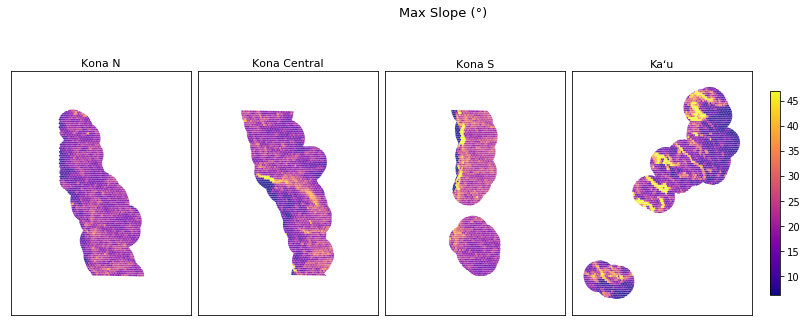

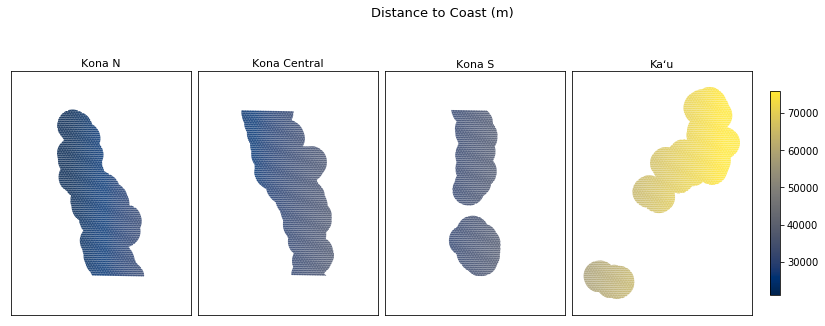

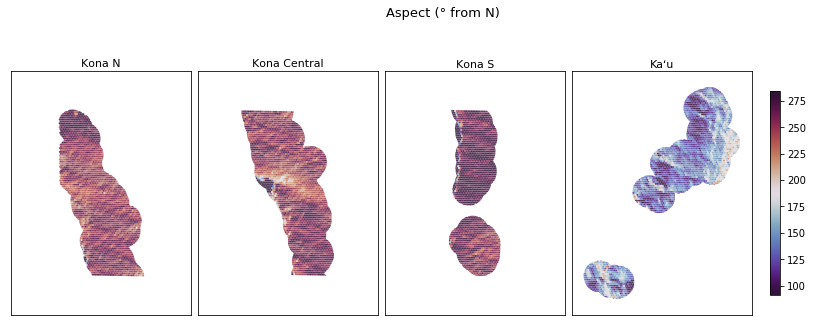

In [8]:
import warnings
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

SPLIT_LON = -155.7279
BG = '#111111'

def clip_cmap(name, lo=0.0, hi=0.9):
    """Clip colormap to avoid the near-white tip at the bright end."""
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(
        f'{name}_clip', base(np.linspace(lo, hi, 256))
    )

def plot_regions(gdf, col, title, cmap, fname):
    cx = gdf.geometry.centroid.x
    cy = gdf.geometry.centroid.y

    kona = gdf[cx < SPLIT_LON]
    kau  = gdf[cx >= SPLIT_LON]

    kona_cy = cy[kona.index]
    lat_min, lat_max = kona_cy.min(), kona_cy.max()
    cut1 = lat_min + (lat_max - lat_min) / 3
    cut2 = lat_min + 2 * (lat_max - lat_min) / 3

    kona_n = kona[kona_cy >= cut2]
    kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
    kona_s = kona[kona_cy < cut1]

    ab = kau.total_bounds
    span_w = (ab[2] - ab[0]) * 1.15
    span_h = (ab[3] - ab[1]) * 1.15

    def centroid(region):
        b = region.total_bounds
        return (b[0]+b[2])/2, (b[1]+b[3])/2

    panels = [
        (kona_n, 'Kona N'),
        (kona_m, 'Kona Central'),
        (kona_s, 'Kona S'),
        (kau,    "Ka\u02BBu"),
    ]

    vmin = gdf[col].quantile(0.02)
    vmax = gdf[col].quantile(0.98)

    fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                             gridspec_kw={'hspace': 0.06, 'wspace': 0.04})
    fig.patch.set_facecolor(BG)

    for ax, (region, label) in zip(axes.flat, panels):
        rx, ry = centroid(region)
        ax.set_facecolor(BG)
        region.plot(ax=ax, column=col, cmap=cmap,
                    vmin=vmin, vmax=vmax,
                    legend=False, edgecolor='none', alpha=0.9)
        ax.set_xlim(rx - span_w/2, rx + span_w/2)
        ax.set_ylim(ry - span_h/2, ry + span_h/2)
        ax.set_title(label, fontsize=12, pad=5, color='white')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#333333')

    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=25)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(['min', 'max'])
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=10)
    cbar.outline.set_edgecolor('#333333')

    fig.suptitle(title, fontsize=14, color='white', y=1.01)
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

plot_vars = [
    ('elev_mean',    'Mean Elevation (m)',    clip_cmap('viridis'),          '../img/03_elev.png'),
    ('slope_max',    'Max Slope (°)',          clip_cmap('plasma'),           '../img/03_slope.png'),
    ('dist_coast_m', 'Distance to Coast (m)', clip_cmap('magma',  lo=0.1),   '../img/03_coast.png'),
    ('aspect_mean',  'Aspect (° from N)',      'twilight_shifted',            '../img/03_aspect.png'),
]
for col, title, cmap, fname in plot_vars:
    plot_regions(gdf_features, col, title, cmap, fname)
